# JT-SURF 2026 

The code below is the compilation of work completed during the Summer 2026 JT-SURF program at the Scripps Institute of Oceanography. Using a pseudo-atmosphere with controlled errors, it is the hope to see how machine learning and AI can be used to accurately forecast weather ptomatoictions.

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import plotly.express as px
import pandas as pd

#Lorenz's parameters
sigma = 10
beta = 8/3
rho = 28

In [4]:
# dy is a vector of the derivatives of the state variables, which are calculated based on the current state and the Lorenz equations.
# The function returns the derivatives as a numpy array.
def lorenz(t, y):

    dy = [sigma * (y[1] - y[0]), 
            y[0] * (rho - y[2]) - y[1],
            y[0] * y[1] - beta * y[2]]
    return np.array(dy)

In [5]:
# RK4 Integrator
# fun is the ODE, dt is the timestep, t0 is the current time, and y0 is the current state
# function (x, t) -> function (t,y)
def rk4_step(fun, dt, t0, y0):
    f1 = fun(t0, y0)    #t0 equivalent to Xk
    f2 = fun(t0 + dt/2, y0 + dt/2 * f1)
    f3 = fun(t0 + dt/2, y0 + dt/2 * f2)
    f4 = fun(t0 + dt, y0 + dt * f3)
    yout = y0 + (dt/6) * (f1 + 2*f2 + 2*f3 + f4)
    return yout

In [6]:
#Forward Euler integration
def euler_step(y0, T, dt):
    # Compute the total number of time steps
    steps = int(T / dt) #Time steps = Total time / time step
    X = np.zeros((3, steps + 1)) 
    X[:, 0] = y0 #initialize the first column X with the initial condition y0 with 0 steps + 1 columns for the time steps
    x = y0.copy() #separate block of memory for the current state x to avoid modifying the original initial condition y0

    # Forward Euler integration
    for k in range(1, steps + 1):
        x = x + dt * lorenz(0, x)  # Update the state using the Lorenz equations
        X[:, k] = x  # Store the updated state in the trajectory array

    t = np.arange(0, T + dt, dt)
    return X, t  # Return the trajectory and corresponding time points

## Solve using various methods

In [7]:
# Initial conditions
y0 = np.array([1, 1, 1])      # Starting point in the Lorenz system

# Compute trajectrory using RK4
dt = 0.01                        #time steps 
T = 100                         #total time 

num_time_pts = int(T / dt) + 1 # number of time points and shows hoa many time values there are from the start to the end of the simulation. 
t_eval = np.linspace(0, T, num_time_pts) # use linspace to create a time vector 

#Solve using rk4
Y = np.zeros((3, num_time_pts)) # Y array holds the state variables of Xk through each step of the RK4 integration. 
Y[:, 0] = y0                    # Starting with y0 as the initial condition for the first column of Y. Continues to fill the Y array with the state variables at each time step.
yin = y0
for i in range (num_time_pts - 1):
    yout = rk4_step(lorenz, dt, t_eval[i], yin)
    Y[:, i + 1] = yout
    yin = yout
print("R4K first 10:" + str(Y[:, :10]))

# Solve using solve_ivp
lorenz_solution = solve_ivp(
    lorenz,
    [0, T],
    y0,
    t_eval=t_eval,
    method='RK45'
)
print("solve_ivp first 10:" + str(lorenz_solution.y[:, :10]))

t_ivp = lorenz_solution.t
y_ivp = lorenz_solution.y

#Solve using Euler 
Y_euler, t_euler = euler_step(y0, T, dt)
print("Euler first 10:" + str(Y_euler[:, :10])) 


R4K first 10:[[1.         1.01256719 1.04882371 1.10720885 1.18686802 1.28755706
  1.40957066 1.55369006 1.72114638 1.9135962 ]
 [1.         1.2599178  1.52399713 1.79830989 2.08854014 2.40015446
  2.73854561 3.10915397 3.51756946 3.96961501]
 [1.         0.98489097 0.97311422 0.96515895 0.96173722 0.96380606
  0.97260817 0.98973112 1.01718652 1.05751186]]
solve_ivp first 10:[[1.         1.01250173 1.04874748 1.10721892 1.18688502 1.28737381
  1.40927574 1.55351236 1.72123822 1.9138408 ]
 [1.         1.26000473 1.52409671 1.79829956 2.08852624 2.40041056
  2.73893868 3.10938652 3.51746944 3.96934229]
 [1.         0.98489066 0.97311751 0.96517068 0.96176026 0.96387831
  0.97268411 0.98976573 1.01719668 1.05753588]]
Euler first 10:[[1.         1.         1.026      1.07515667 1.14561318 1.23631717
  1.34688354 1.47749235 1.62881421 1.80195727]
 [1.         1.26       1.51756667 1.77972176 2.05265312 2.3419809
  2.65297159 2.990711   3.3602448  3.7666926 ]
 [1.         0.98333333 0.969711

## Plot Trajectory in time and 3D space

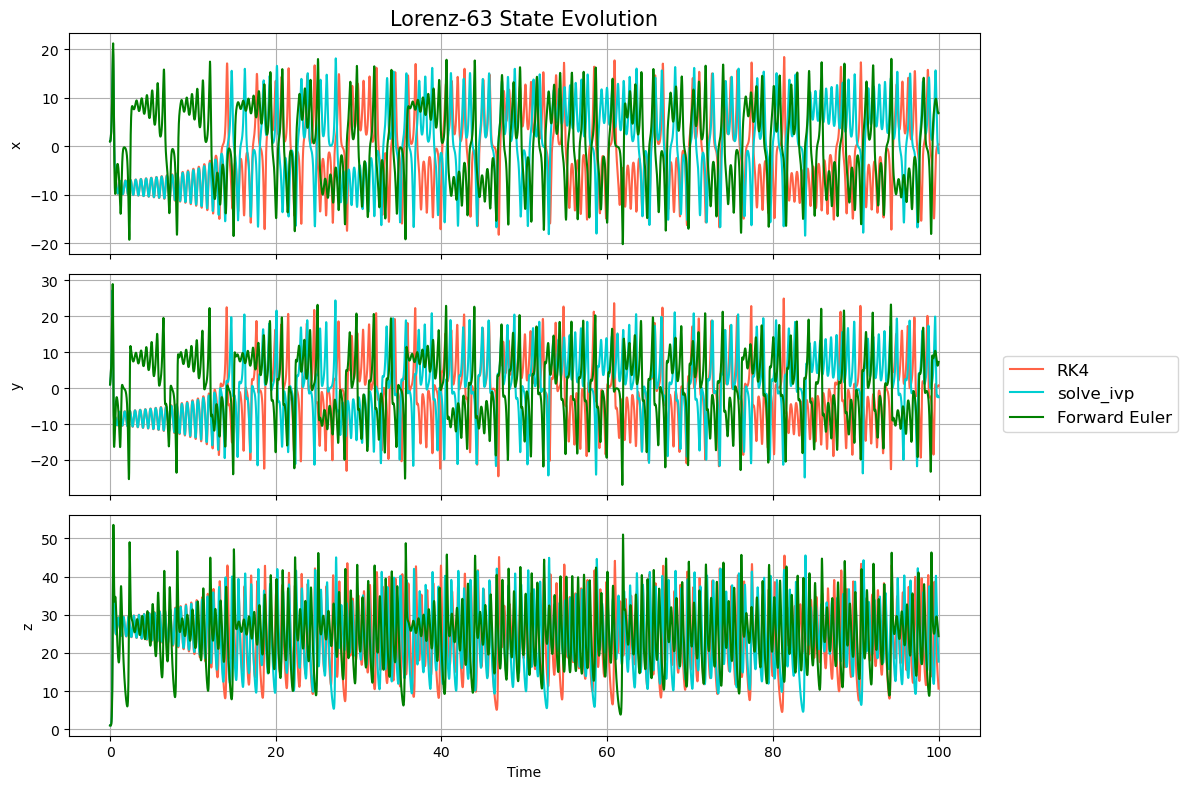

In [8]:
#Plot state evolution as a function of time 
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# x(t)
ax[0].plot(t_eval, Y[0, :], color='tomato', label='RK4')
ax[0].plot(t_ivp, y_ivp[0, :], color='darkturquoise', label='solve_ivp')
ax[0].plot(t_euler, Y_euler[0, :], color='green', label='Forward Euler')
ax[0].set_ylabel('x')
ax[0].set_title('Lorenz-63 State Evolution', fontsize=15)
ax[0].grid(True)

# y(t)
ax[1].plot(t_eval, Y[1, :], color='tomato', label='RK4')
ax[1].plot(t_ivp, y_ivp[1, :], color='darkturquoise', label='solve_ivp')
ax[1].plot(t_euler, Y_euler[1, :], color='green', label='Forward Euler')
ax[1].set_ylabel('y')
ax[1].grid(True)

# z(t)
ax[2].plot(t_eval, Y[2, :], color='tomato', label='RK4')
ax[2].plot(t_ivp, y_ivp[2, :], color='darkturquoise', label='solve_ivp')
ax[2].plot(t_euler, Y_euler[2, :], color='green', label='Forward Euler')
ax[2].set_ylabel('z')
ax[2].set_xlabel('Time')
ax[2].grid(True)

# One legend outside the figure
fig.legend(
    ['RK4', 'solve_ivp', 'Forward Euler'],
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize = 12
)

plt.tight_layout()
plt.show()

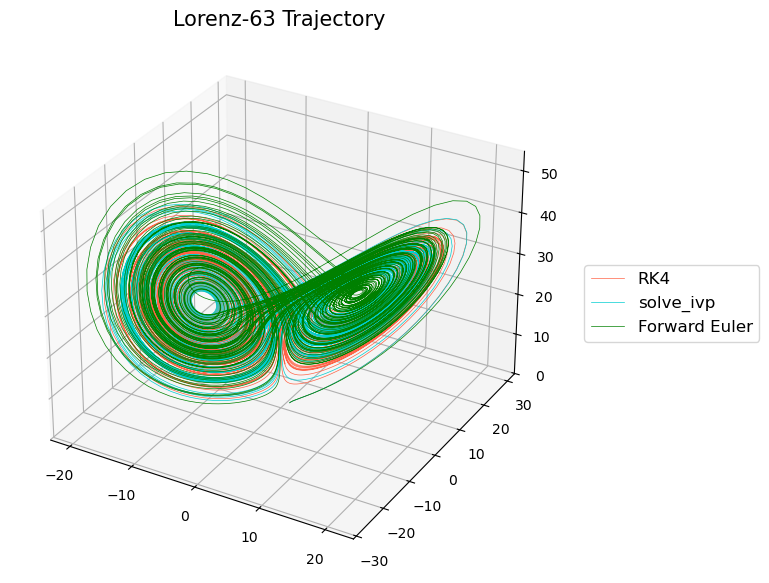

In [9]:
# Plot the trajectory in 3D phase space between the x, y, and z space. 
# The tomato line represents the forward euler solution, while the green  line represents the solution obtained using solve_ivp. Ther blue line represents the solution obtained using RK4.
ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
ax.set_title('Lorenz-63 Trajectory', fontsize=15)
ax.plot(Y[0, :], Y[1, :], Y[2, :], color='tomato', lw=0.5, label = 'RK4')
ax.plot(y_ivp[0, :], y_ivp[1, :], y_ivp[2, :], color='darkturquoise', lw=0.5, label = 'solve_ivp')
ax.plot(Y_euler[0, :], Y_euler[1, :], Y_euler[2, :], color='green', lw=0.5, label = 'Forward Euler')

ax.legend(
    ['RK4', 'solve_ivp', 'Forward Euler'],
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    fontsize = 12
)

plt.show()

### The code below is used to plot and create an interactive html for the trajectory in 3D space. 

In [ ]:
# import plotly.graph_objects as go
# #Plot state evolution in interactive x, y, z, space. 
# ax = plt.figure(figsize=(7,7)).add_subplot(projection='3d')
# ax.set_title('Lorenz-63 Trajectory', fontsize=15)
# ax.plot(Y_euler[0, :], Y_euler[1, :], Y_euler[2, :], color='blue', lw=0.5, label = 'Forward Euler')
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.grid(True)

# ax.legend(
#     ['Forward Euler'],
#     loc='center left',
#     bbox_to_anchor=(1.05, 0.5),
#     fontsize = 12
# )

# fig = plt.figure(figsize=(7,7))
# ax = fig.add_subplot(projection='3d')

# #Create a clear background for the final result. 
# ax.plot(
#     Y_euler[0, :],
#     Y_euler[1, :],
#     Y_euler[2, :],
#     color='blue',
#     lw=0.5,
#     label='Forward Euler'
# )

# # Remove grid
# ax.grid(False)

# # Remove the gray background panes
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False

# # Make pane edges invisible
# ax.xaxis.pane.set_edgecolor('none')
# ax.yaxis.pane.set_edgecolor('none')
# ax.zaxis.pane.set_edgecolor('none')

# # Remove axis lines, ticks, and labels
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_zticks([])

# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.set_zlabel("")

# # Hide the axis frame
# ax.set_axis_off()


# fig = go.Figure()

# fig.add_trace(
#     go.Scatter3d(
#         x=Y_euler[0, :],
#         y=Y_euler[1, :],
#         z=Y_euler[2, :],
#         mode='lines',
#         line=dict(color='blue', width=2),
#         name='Forward Euler'
#     )
# )

# fig.update_layout(
#     title='Lorenz-63 Trajectory',
#     scene=dict(
#         xaxis_visible=False,
#         yaxis_visible=False,
#         zaxis_visible=False,
#         bgcolor='white'
#     ),
#     showlegend=False
# )

# fig.write_html("Euler_interactive.html")

In [10]:
# !!! Turn plotting into a function


# def create_3d_plot(data, title):
#     df = pd.DataFrame(data)
#     fig = px.scatter_3d(df, x='X', y='Y', z='Z', title=title)
#     fig.update_traces(mode='lines', line=dict(width=2))
#     fig.update_layout(width=600, height=600)
#     return fig

#Euler Interactive 3D Plot
df = pd.DataFrame({
    'X': Y_euler[0, :],
    'Y': Y_euler[1, :],
    'Z': Y_euler[2, :]
})

fig = px.scatter_3d(df, x='X', y='Y', z='Z', title="Interactive 3D Plot - Lorenz63 Euler")
fig.update_traces(mode='lines', line=dict(width=2))
fig.update_layout(width=600, height=600,
#     scene=dict(
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         zaxis=dict(visible=False),
#         bgcolor="rgba(0,0,0,0)"
#     ),
#     paper_bgcolor="white",
)
fig.show()

df = pd.DataFrame({
    'X': y_ivp[0, :],
    'Y': y_ivp[1, :],
    'Z': y_ivp[2, :]
})

fig = px.scatter_3d(df, x='X', y='Y', z='Z', title="Interactive 3D Plot - solve_ivp")
fig.update_traces(mode='lines', line=dict(width=2))
fig.update_layout(width=600, height=600)
fig.show()

df=pd.DataFrame({
    'X': Y[0, :],
    'Y': Y[1, :],
    'Z': Y[2, :]
})

fig = px.scatter_3d(df, x='X', y='Y', z='Z', title="Interactive 3D Plot - Lorenz63 RK4")
fig.update_traces(mode='lines', line=dict(width=2))
fig.update_layout(width=600, height=600)
fig.show()


## Simulating Lorenz through Numerical Integration

Visualizing the cube of uncertainty is helpful to illustrate how the saddle plays a role in the Lorenz System.

In [ ]:
# # Initial conditions - Large cube of points 
# n = 10 
# xvec =  np.linspace(-20, 20, n) # Create a vector of initial conditions for x, y, and z
# yvec =  np.linspace(-20, 20, n)
# zvec =  np.linspace(-20, 20, n)
# [x0,y0,z0] = np.meshgrid(xvec, yvec, zvec) # Create a meshgrid of initial conditions for x, y, and z

# yIC = np.zeros((3, n**3)) # Initialize an array to hold the initial conditions
# yIC[0, :] = x0.reshape(n ** 3) # Flatten the meshgrid and assign to the first row
# yIC[1, :] = y0.reshape(n ** 3) # Flatten the meshgrid and assign to the second row
# yIC[2, :] = z0.reshape(n ** 3) # Flatten the meshgrid and assign to the third row

# ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
# ax.plot(yIC[0, :], yIC[1, :], yIC[2, :], 'o', markersize=3, color='blue', lw=0.5, label = 'Initial Conditions')
# ax.set_title('Lorenz-63 Initial Conditions', fontsize=15)
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# plt.xlim(-40, 40)
# plt.ylim(-40, 40)
# ax.set_zlim(-40, 40)
# plt.show()

In [ ]:
import sys
print(sys.executable)

In [ ]:
# #THIS IS THE SLOW ALGORITHM TO DEMONSTRATE CHAOTIC SYSTEMS.
# from time import time
# from matplotlib import animation, lines 
# %matplotlib notebook

# #Compute trajectory 
# dt = 0.01
# nt = int(50/dt)
# t = np.linspace(0, 50, nt)

# lorenz_solution = solve_ivp(lorenz, (0, 50), y0, t_eval=t, method='RK45')
# y = lorenz_solution.y.T

# ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
# ax.plot(y[:, 0], y[:, 1], y[:, 2], 'k')

# #Initial Condition 1 - Large cube of points
# # this code is slow because python is not compiled and the for loops are not optimized.
# # we use nested for loops to step through every single IC and compute the trajectory one. at. a. time. 
# y0 = [1, 1, 1]
# n = 10
# xvec =  np.linspace(-20, 20, n)
# yvec =  np.linspace(-20, 20, n)
# zvec =  np.linspace(-20, 20, n)

# #Initial condition 2 - small cube around initial condition
# y0 = [1, 1, 1]
# # xvec =  np.linspace(-1, 1, n)
# # yvec =  np.linspace(-1, 1, n)
# # zvec =  np.linspace(-1, 1, n)

# #Initial condition 3 - small cube around initial condition
# y0 = [1, 1, 1]
# # xvec =  np.linspace(-0.1, 0.1, n)
# # yvec =  np.linspace(-0.1, 0.1, n)
# # zvec =  np.linspace(-0.1, 0.1, n)

# [x0,y0,z0] = np.meshgrid(xvec + y0[0], yvec + y0[1], zvec + y0[2])
# yIC = np.zeros((3, n**3))
# yIC[0, :] = x0.reshape(n ** 3)
# yIC[1, :] = y0.reshape(n ** 3)
# yIC[2, :] = z0.reshape(n ** 3)

# #ax.plit(yIC[0, :], yIC[1, :], yIC[2, :], 'o', markersize=3, color='blue', lw=0.5, label = 'Initial Conditions')
# plt.xlim(-40, 40)
# plt.ylim(-40, 40)
# ax.set_zlim(-40, 40)

# #Compute trajectory 
# dt = 0.01
# duration = 4
# t_span = [0, duration]
# L = int(duration/dt)
# yin = yIC
# y_single_steps = np.zeros((3, L, n ** 3))

# start_time = time()
# for step in range (L):
#     tstep = step * dt
#     yout = rk4_step(lorenz, dt, tstep, yin)
#     yin = yout
#     y_single_steps[:, step, :] = yout
# end_time = time()
# print ("Total Time Elapsed: " + str(end_time - start_time) + " seconds")




# Neural Networks 
This part of the code will focus on the creation and training of neural networks using pytorch 

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [12]:
#Load the Dataset and preview
df1 = pd.read_csv("/Users/kylamonique/Documents/UCSDSURF/Data/DataSet2.txt", sep="\t", names=["Input", "Output"]) 
df1

,Input,Output
0,1,0.80
1,2,0.84
2,3,0.82
3,4,0.81
4,5,0.83
...,...,...
195,196,0.92
196,197,0.91
197,198,0.94
198,199,0.92


In [13]:
#Summary statistics of the dataset
df1.describe()

,Input,Output
count,200.000000,200.000000
mean,100.500000,1.107400
std,57.879185,0.392367
min,1.000000,0.640000
25%,50.750000,0.810000
50%,100.500000,0.935000
75%,150.250000,1.450000
max,200.000000,2.330000


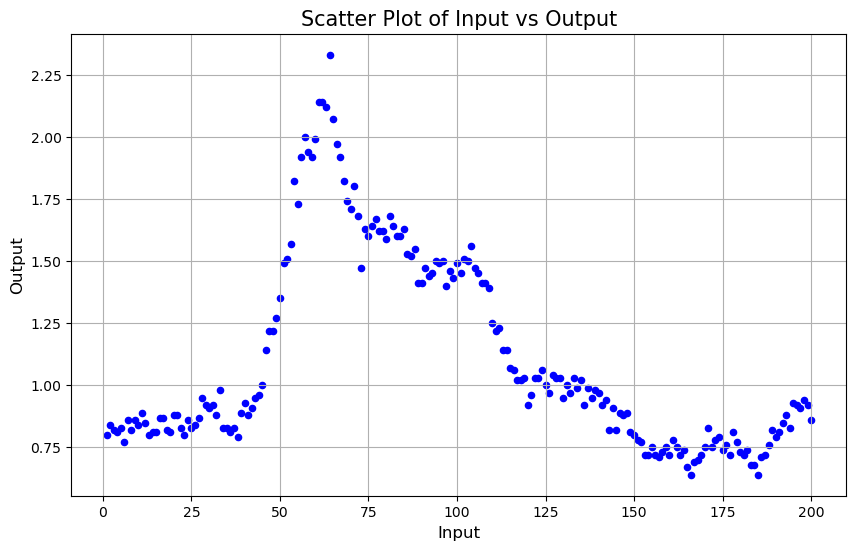

In [14]:
#Plotting the DataSet
plt.figure(figsize=(10, 6))

plt.scatter(df1['Input'], df1['Output'], color='blue', s=20)
plt.title('Scatter Plot of Input vs Output', fontsize=15)
plt.xlabel('Input', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.grid(True)


In [15]:
#Separate the inputs and outputs
X = df1[['Input']]
Y = df1[['Output']]

print (X.shape)
print (Y.shape)

(200, 1)
(200, 1)


In [16]:
#Train, Test, Split 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.head()

,Input
79,80
197,198
38,39
24,25
122,123


In [23]:
#Convert the data toPyTorch tensors for Neural Network Training. 
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32)

print(X_train_tensor.shape)
print(Y_train_tensor.shape)
print (X_test_tensor.shape)
print (Y_test_tensor.shape)

torch.Size([160, 1])
torch.Size([160, 1])
torch.Size([40, 1])
torch.Size([40, 1])


In [24]:
#Build the Neural Network
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        #Define the architecture of the neural network using a sequential model. 
        self.network = nn.Sequential(
           
           #Input layer with 1 input feature and 20 output features, followed by a Tanh activation function
            nn.Linear(1, 200),
            nn.Tanh(), #Tanh allows for non-linear transformations of the input data, enabling the network to learn complex relationships.

            #Output layer with 20 input features and 20 output features, this maps the 20 outputs from the first layer
            # to a 20 neurons in the hidden layer, followed by a Tanh activation function.
            nn.Linear(200,200),
            nn.Tanh(), 
            
            nn.Linear(200,200),
            nn.Tanh(), 
            
            #Reduces the 20 outputs from the hidden layer to a single output value, which is the final prediction of the network.
            nn.Linear(200,1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
deepmodel = NeuralNetwork()
criterion = nn.MSELoss() #Mean Squared Error Loss function, which measures the average squared difference between the predicted and actual values.
optimizer = torch.optim.Adam(
    deepmodel.parameters(),
    lr=0.01) #Learning rate 


In [28]:
#Train the Model 
epochs = 1000

loss_history = []

'''
Create the loss function and optimizer for training the neural network. 
The loss function measures the difference between the predicted outputs and the actual outputs, 
while the optimizer updates the model's parameters to minimize this loss during training.
'''

for epoch in range(epochs):

    prediction = deepmodel(X_train_tensor)
    loss = criterion(prediction, Y_train_tensor)
    optimizer.zero_grad()
    loss.backward() 
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

Epoch 0: Loss = 1.264450
Epoch 10: Loss = 0.168186
Epoch 20: Loss = 0.243428
Epoch 30: Loss = 0.183935
Epoch 40: Loss = 0.136309
Epoch 50: Loss = 0.135793
Epoch 60: Loss = 0.135984
Epoch 70: Loss = 0.135344
Epoch 80: Loss = 0.134990
Epoch 90: Loss = 0.134899
Epoch 100: Loss = 0.134911
Epoch 110: Loss = 0.134915
Epoch 120: Loss = 0.134901
Epoch 130: Loss = 0.134898
Epoch 140: Loss = 0.134899
Epoch 150: Loss = 0.134898
Epoch 160: Loss = 0.134898
Epoch 170: Loss = 0.134898
Epoch 180: Loss = 0.134898
Epoch 190: Loss = 0.134898
Epoch 200: Loss = 0.134898
Epoch 210: Loss = 0.134898
Epoch 220: Loss = 0.134898
Epoch 230: Loss = 0.134898
Epoch 240: Loss = 0.134898
Epoch 250: Loss = 0.134898
Epoch 260: Loss = 0.134898
Epoch 270: Loss = 0.134898
Epoch 280: Loss = 0.134898
Epoch 290: Loss = 0.134898
Epoch 300: Loss = 0.134898
Epoch 310: Loss = 0.134898
Epoch 320: Loss = 0.134898
Epoch 330: Loss = 0.134898
Epoch 340: Loss = 0.134898
Epoch 350: Loss = 0.134898
Epoch 360: Loss = 0.134898
Epoch 370: L

In [35]:
#Evaluation
deepmodel.eval()

with torch.no_grad():
    train_prediction = deepmodel(X_train_tensor)
    train_loss = criterion(train_prediction, Y_train_tensor)
        
    test_prediction = deepmodel(X_test_tensor)
    test_loss = criterion(test_prediction, Y_test_tensor)

print("Train Loss:", train_loss.item())
print("Test Loss:", test_loss.item())

Train Loss: 0.13489773869514465
Test Loss: 0.22962570190429688


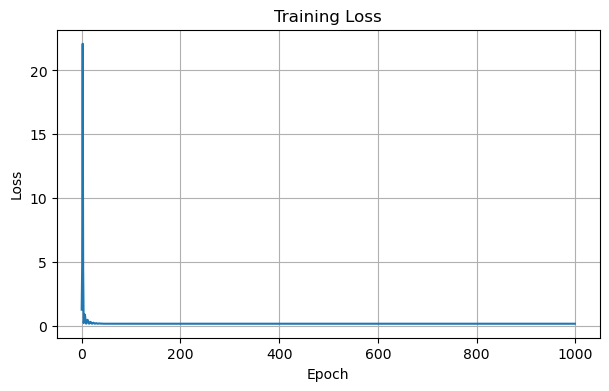

In [244]:
#Plot the Training Loss 
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()


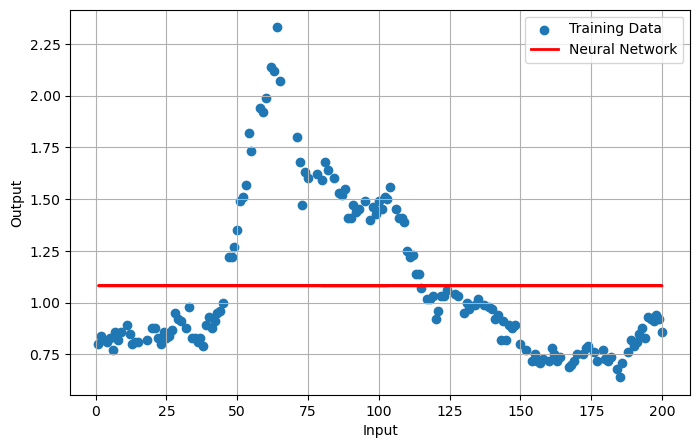

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_train_tensor.numpy(),
    Y_train_tensor.numpy(),
    label="Training Data"
)

plt.plot(
    X_train_tensor.numpy(),
    prediction.numpy(),
    color="red",
    linewidth=2,
    label="Neural Network"
)

plt.xlabel("Input")
plt.ylabel("Output")

plt.legend()
plt.grid(True)

plt.show()

## Neural Networks - Stochastic Gradient Descent

## Extra Code Chunks